In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-01-29 09:28:39.507018


careful more than one adata

# Dual-innervating

In [2]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [3]:
plt.rcParams['figure.figsize'] = (4,4)
plt.rcParams["figure.dpi"] = 300

In [4]:
# adata

base_dir = "/home/workspace/DRG"
input_file = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/20260115_drg-gpu-backup/data/h5ad/export_04/04c_gamma_subtypes/neurons-final-labels.h5ad"
output_dir = os.path.join(base_dir, "spatial_mouse_drg_outputs/Kim/update_thresholds_method2b")
plot_out_dir = os.path.join(output_dir, "plots")

# updated reporter identification
reporter_classes_updated_dual_neurons = pd.read_csv(os.path.join(output_dir, 'reporter_classes_updated_dual_neurons.csv'), index_col = 0)

In [5]:
adata = sc.read_h5ad(input_file)

In [6]:
# update reporter ids based on KA thresholding updates
cols_update = ['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status']
for col in cols_update:
    if col in adata.obs.columns:
        print(f"deleting {col}")
        del adata.obs[col]

adata.obs = adata.obs.join(reporter_classes_updated_dual_neurons[['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi']])

# add reporter status, either single positive or double postivie
adata.obs['reporter_status'] = 'none'
adata.obs.loc[adata.obs['EGFP_Seq1_hi']==True, 'reporter_status'] = 'EGFP_Seq1_hi'
adata.obs.loc[adata.obs['dTomato_Seq2_hi']==True, 'reporter_status'] = 'dTomato_Seq2_hi'
adata.obs.loc[adata.obs['EGFP_dTomato_dual_hi']==True, 'reporter_status'] = 'EGFP_dTomato_dual_hi'

deleting EGFP_Seq1_hi
deleting dTomato_Seq2_hi
deleting EGFP_dTomato_dual_hi
deleting reporter_status


In [7]:
# Show single+ all together
counts_series = adata.obs.value_counts(['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi'])
counts_df = counts_series.reset_index(name='cell_count')
counts_df

,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,cell_count
0,False,False,False,22120
1,True,False,False,139
2,False,True,False,133
3,True,True,True,19


In [8]:
# adata.X = adata.layers['log1p'].copy()

### Plot

In [9]:
plt.rcdefaults()
plt.rcParams["figure.dpi"] = 150

## Functions

In [10]:
def kde_grid_plot(
    adata,
    genes,
    group_col="EGFP_dTomato_dual_hi",   # group column to compare True vs False
    ncols=5,                             # number of columns in grid
    figsize=(12, 6),
    gene_fontsize=14                     # NEW: control gene title size
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import pandas as pd
    import math

    sns.set_theme(style="ticks")

    # --- Robust conversion of group_col to boolean ---
    raw_group = adata.obs[group_col]

    if isinstance(raw_group.dtype, pd.CategoricalDtype):
        group_bool = raw_group.astype(str) == "True"
    elif raw_group.dtype == bool:
        group_bool = raw_group.values
    else:
        group_bool = raw_group.astype(str).str.lower().isin(["true", "1", "yes"]).values

    # Extract expression values for each gene
    df = adata.to_df()[genes]

    n = len(genes)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=False,
        sharey=False
    )

    axes = axes.flatten()

    for i, gene in enumerate(genes):
        ax = axes[i]
        x = df[gene].values

        # KDE for False (black)
        sns.kdeplot(
            x[~group_bool],
            ax=ax,
            fill=True,
            color="black",
            alpha=0.25,
            linewidth=3,
            label="False"
        )

        # KDE for True (blue)
        sns.kdeplot(
            x[group_bool],
            ax=ax,
            fill=True,
            color="blue",
            alpha=0.5,
            linewidth=2,
            label="True"
        )

        # --- Italicized, configurable gene name ---
        ax.set_title(
            f"$\\it{{{gene}}}$",
            fontsize=gene_fontsize
        )

        # ax.set_yticks([])
        ax.set_ylabel("")
        ax.tick_params(axis="x", labelsize=8)

    # Hide unused axes (if any)
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    sns.despine()
    plt.tight_layout()

    return fig

## Neuron label Top Marker Genes

In [11]:
adata.obs.seurat_labels.value_counts()

seurat_labels
CGRP-Gamma                    6186
Nonpeptidergic nociceptors    3513
CGRP-Eta                      1963
CGRP-Zeta                     1493
Abeta-RA-LTMR                 1463
Abeta-Field                   1452
C-LTMR                        1402
Adelta-LTMR                   1020
CGRP-Theta                     868
Proprioceptors                 864
TrpM8                          650
CGRP-Epsilion                  609
Sst                            554
CGRP-Alpha                     245
CGRP-Beta                      129
Name: count, dtype: int64

In [12]:
adata.obs["neuron_labels"] = adata.obs["neuron_labels"].astype("category")
adata.obs["neuron_labels"] = adata.obs["neuron_labels"].cat.remove_unused_categories()

In [13]:
sc.tl.rank_genes_groups(adata, groupby="neuron_labels", method="wilcoxon")

In [14]:
markers = sc.get.rank_genes_groups_df(adata, group=None)
markers

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,Abeta-Field,Hapln1,52.491867,3.370802,0.000000e+00,0.000000e+00
1,Abeta-Field,Cntn1,49.403072,1.782196,0.000000e+00,0.000000e+00
2,Abeta-Field,Endod1,46.375473,1.185746,0.000000e+00,0.000000e+00
3,Abeta-Field,Hopx,45.988441,2.061731,0.000000e+00,0.000000e+00
4,Abeta-Field,Gfra1,44.374371,1.716223,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...
7595,TrpM8,Scn10a,-27.428131,-2.618770,1.266999e-165,2.865831e-164
7596,TrpM8,F2rl2,-28.468809,-2.226695,2.851323e-178,7.524323e-177
7597,TrpM8,Resp18,-28.797789,-2.631424,2.286224e-182,6.387980e-181
7598,TrpM8,Asic2,-30.763878,-1.723815,7.976066e-208,3.788631e-206


In [15]:
log2fc_threshold = 2
pval_threshold = 0.05
markers_filtered = markers[
    (markers["logfoldchanges"] > log2fc_threshold)
    & (markers["pvals_adj"] < pval_threshold)
].copy()

#### Extract top 5 genes for each group

In [16]:
top_genes = (
    markers_filtered.sort_values(
        by=["group", "logfoldchanges"], ascending=[True, False]
    )  # Sort by group and log2FC
    .groupby("group")["names"]  
    .head(5)  
    .tolist()  
)

/tmp/ipykernel_118/2505543662.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")["names"]


In [17]:
plt.rcParams["font.size"] = 16

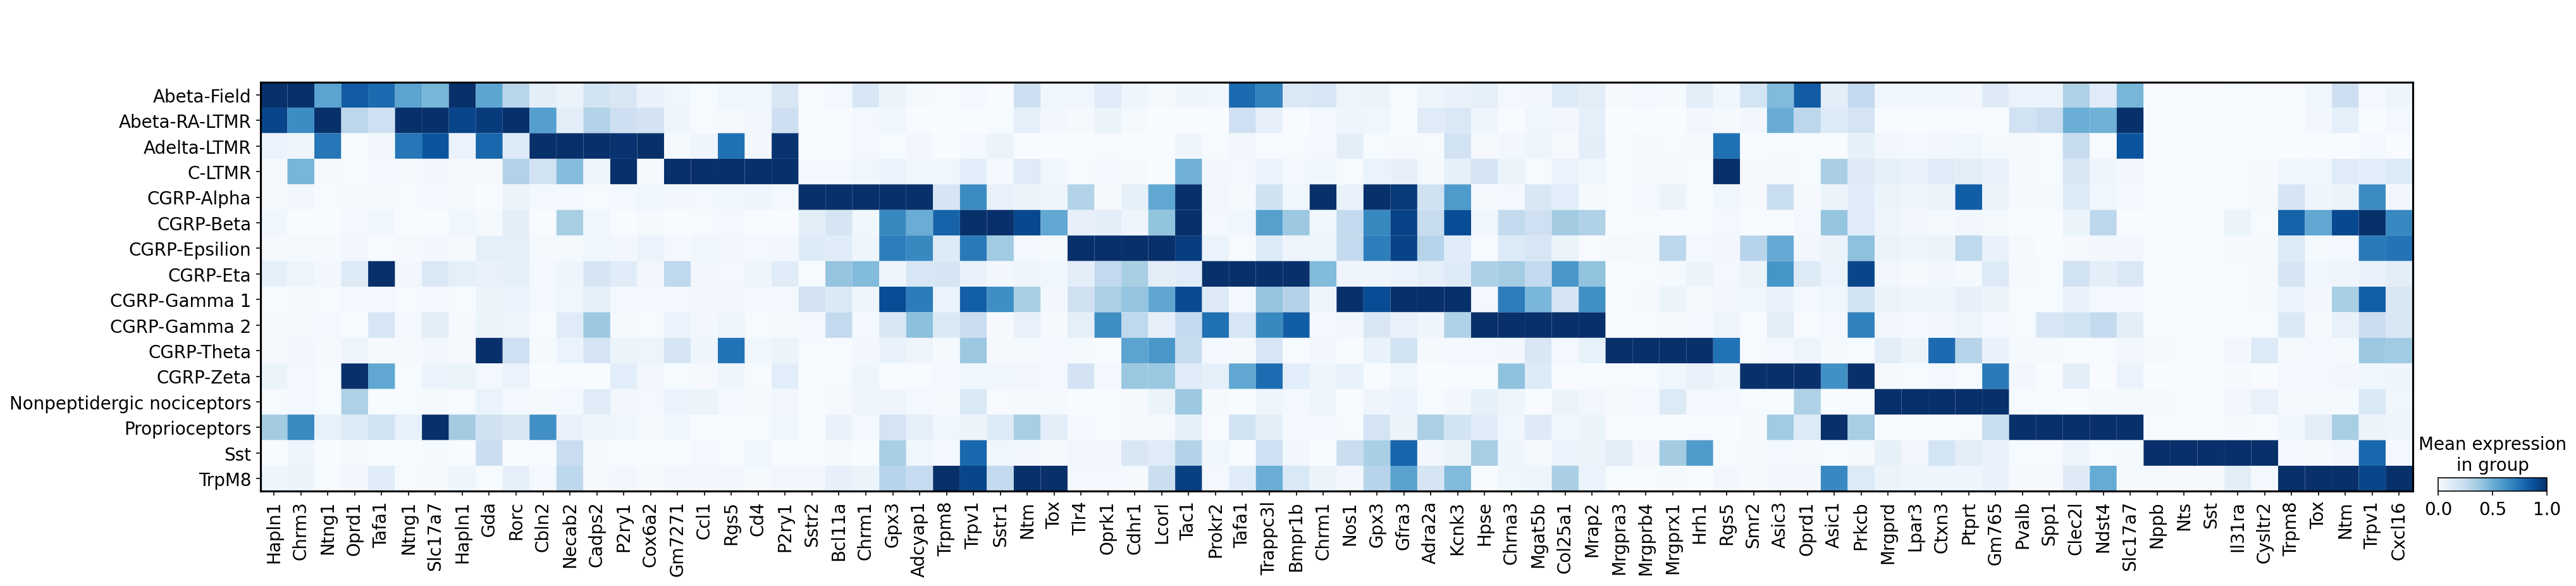

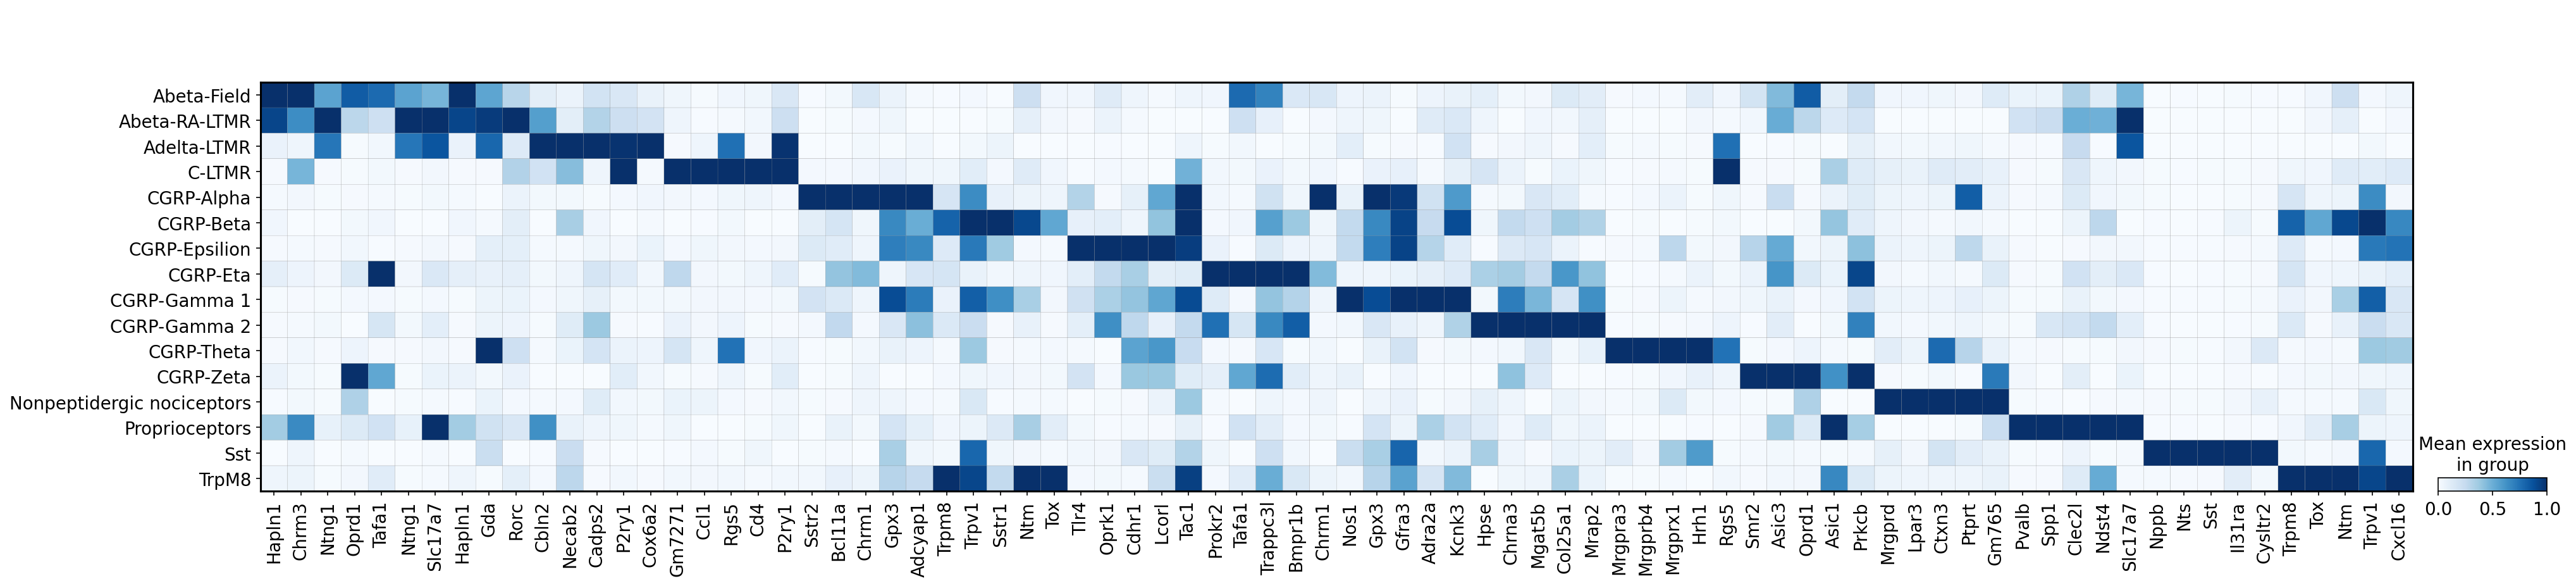

In [18]:
# pdf saving makes the gridlines big, so save both png and pdf, attempting to decrease gridlines
sc.pl.matrixplot(
    adata,
    var_names=top_genes,
    groupby="neuron_label",
    title="",
    standard_scale = 'var',
   # save = '_.pdf',
    cmap = 'Blues',
    edgecolor=None,
    # linewidth= 0.01,
    show=False
)
plt.savefig(os.path.join(plot_out_dir, 'neuron_marker_heatmap.pdf'), bbox_inches='tight', transparent=True)

sc.pl.matrixplot(
    adata,
    var_names=top_genes,
    groupby="neuron_label",
    title="",
    standard_scale = 'var',
   # save = '_.pdf',
    cmap = 'Blues',
    show=False
)
plt.savefig(os.path.join(plot_out_dir, 'neuron_marker_heatmap.png'), bbox_inches='tight', transparent=True)

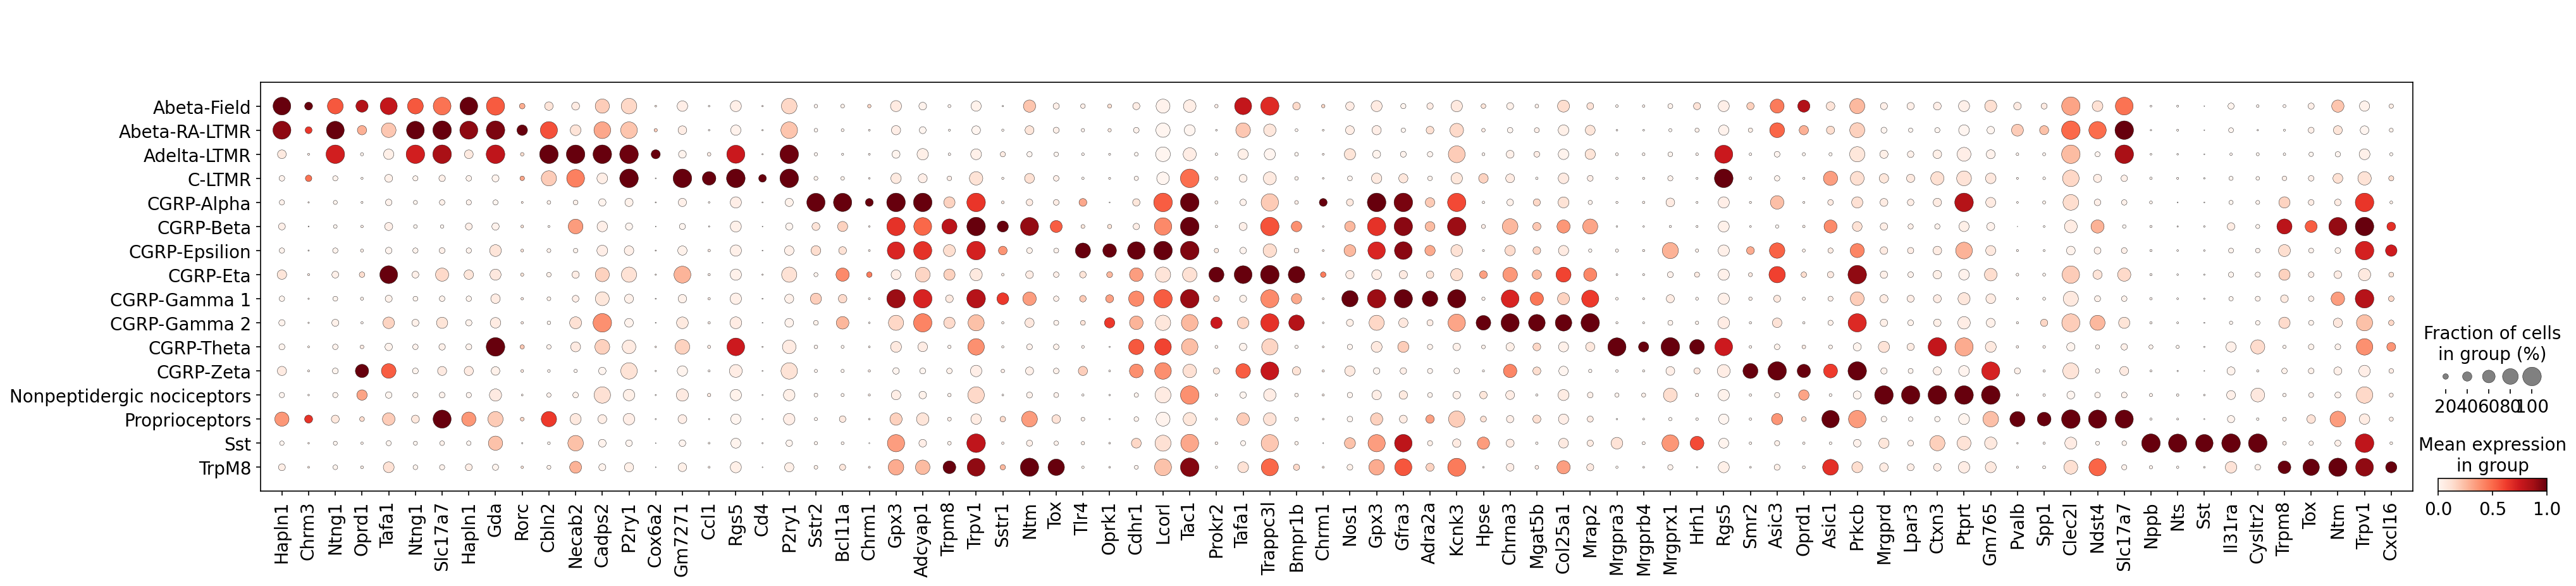

In [19]:
sc.pl.dotplot(
    adata,
    var_names=top_genes,
    groupby="neuron_labels",
    title="",
    standard_scale = 'var',
   # save = '_.pdf',
    cmap = 'Reds'
)

In [20]:
markers_filtered.to_csv(f"{output_dir}/marker-genes-filtered.tsv", 
                        sep="\t", index=False)

markers.to_csv(f"{output_dir}/marker-genes-full.tsv", 
                        sep="\t", index=False)

# Dual-hi marker genes

In [21]:
adata.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    22392
True        19
Name: count, dtype: int64

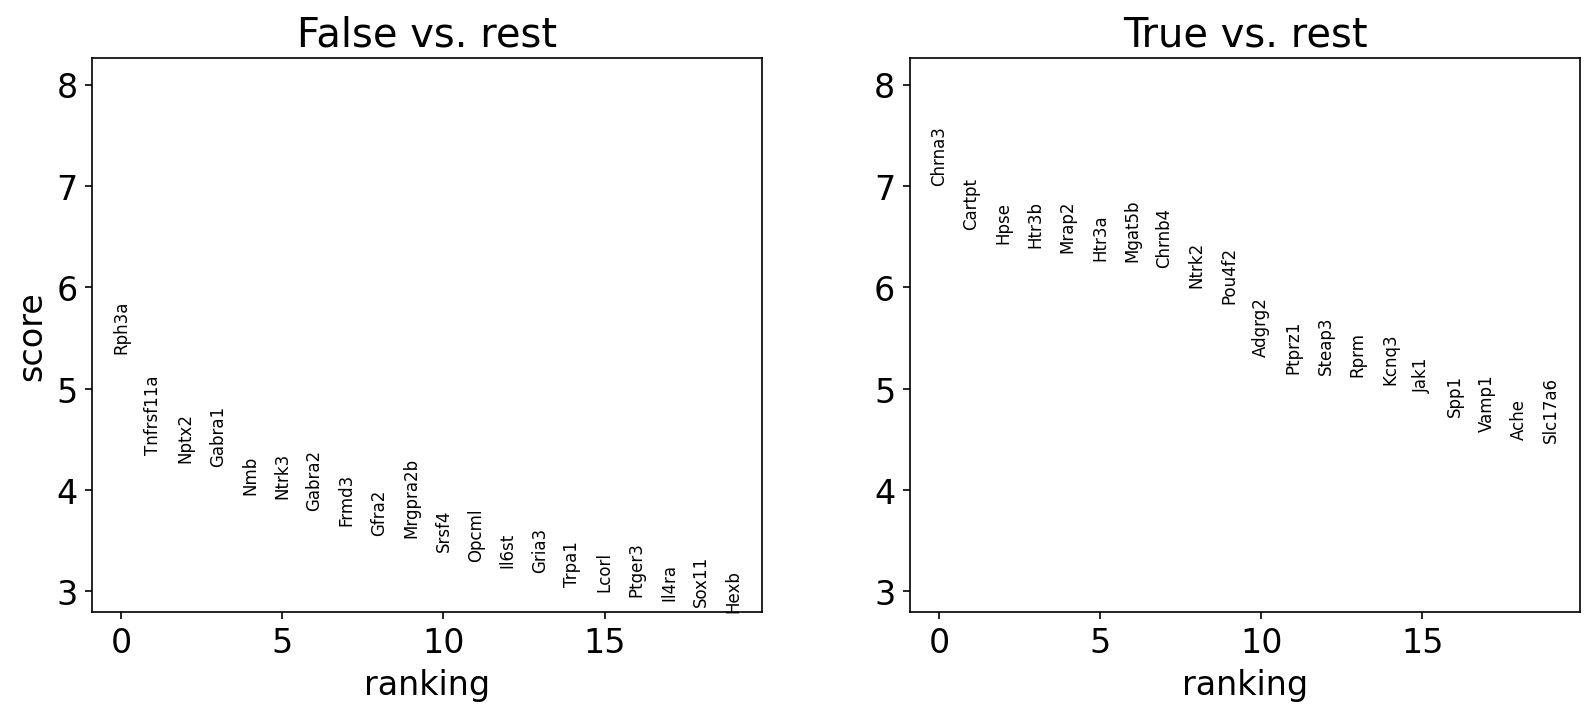

['Chrna3', 'Cartpt', 'Hpse', 'Htr3b', 'Mrap2', 'Htr3a', 'Mgat5b', 'Chrnb4', 'Ntrk2', 'Pou4f2']


In [22]:
adata.obs["EGFP_dTomato_dual_hi"] = adata.obs["EGFP_dTomato_dual_hi"].astype(str)
sc.tl.rank_genes_groups(adata, groupby="EGFP_dTomato_dual_hi", method="wilcoxon")

markers = sc.get.rank_genes_groups_df(adata, group=None)

# plot 
sc.pl.rank_genes_groups(adata, groupby="EGFP_dTomato_dual_hi", method="wilcoxon")

# top dual+ genes
top_genes_dual = (
    markers[markers["group"] == "True"]
    .head(10)["names"]
    .tolist()
)

print(top_genes_dual)

In [23]:
plt.rcParams["font.size"] = 15

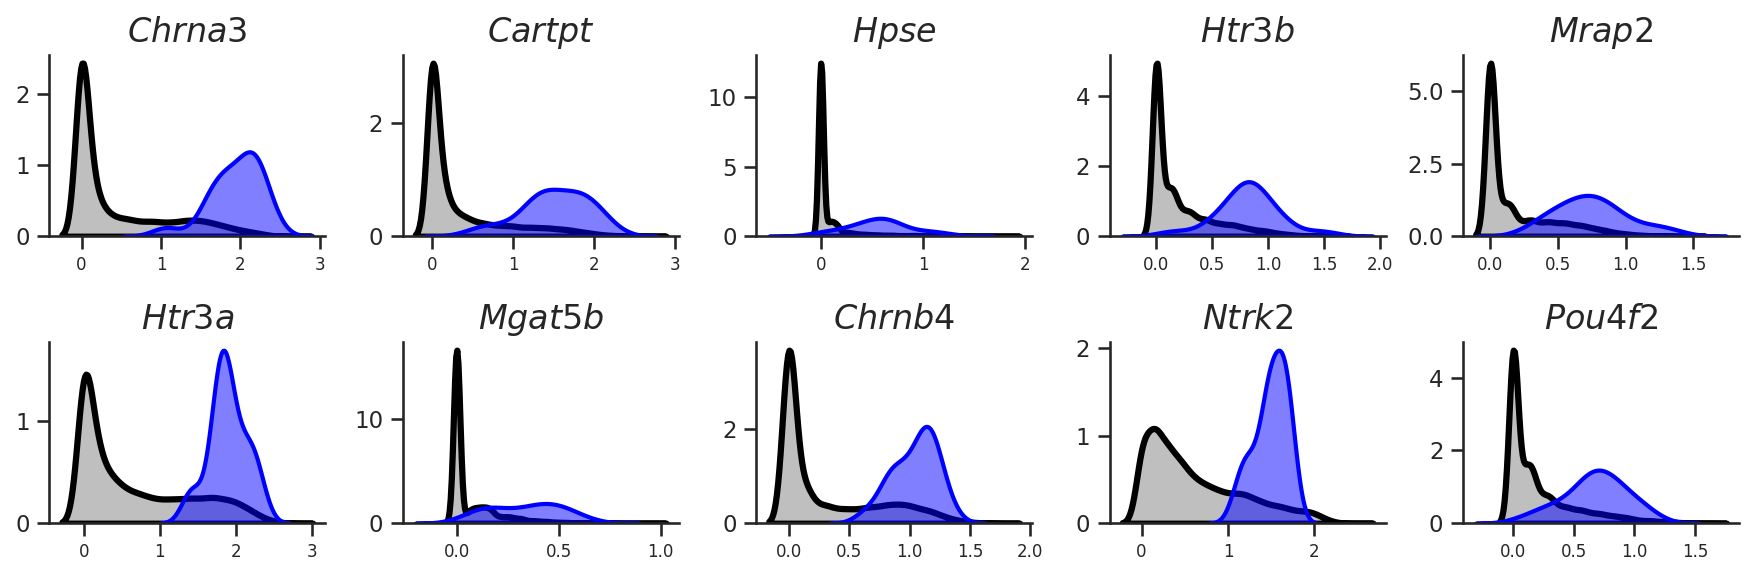

In [24]:
fig = kde_grid_plot(
    adata,
    genes=top_genes_dual,
    group_col="EGFP_dTomato_dual_hi",
    ncols=5,
    figsize=(12, 4),
    gene_fontsize = 16
)
plt.savefig(os.path.join(plot_out_dir, "dual_postive_comparison_allneurons_top10.pdf"), format='pdf', bbox_inches='tight')

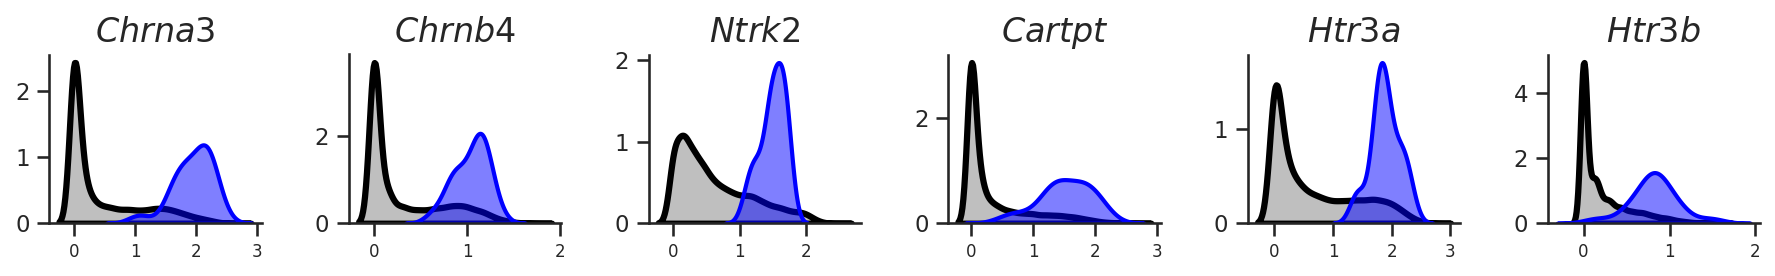

In [25]:

genes = ['Chrna3', 'Chrnb4', 'Ntrk2', 'Cartpt', 'Htr3a', 'Htr3b']
fig = kde_grid_plot(
    adata,
    genes=genes,
    group_col="EGFP_dTomato_dual_hi",
    ncols=6,
    figsize=(12, 2),
    gene_fontsize = 16
)
plt.savefig(os.path.join(plot_out_dir, "dual_postive_comparison_allneurons_top10_select6.pdf"), format='pdf', bbox_inches='tight')

## Dual innervating - CGCRP gamma only 

In [26]:
adata_CGRPg = adata[adata.obs['neuron_label'].isin(['CGRP-Gamma 1', 'CGRP-Gamma 2']), :].copy()
adata_CGRPg.shape

# # below also gives the same
# adata_CGRPg = adata[adata.obs['seurat_labels'] == 'CGRP-Gamma'].copy()
# adata_CGRPg.shape

(6186, 475)

In [27]:
adata_CGRPg.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    6168
True       18
Name: count, dtype: int64

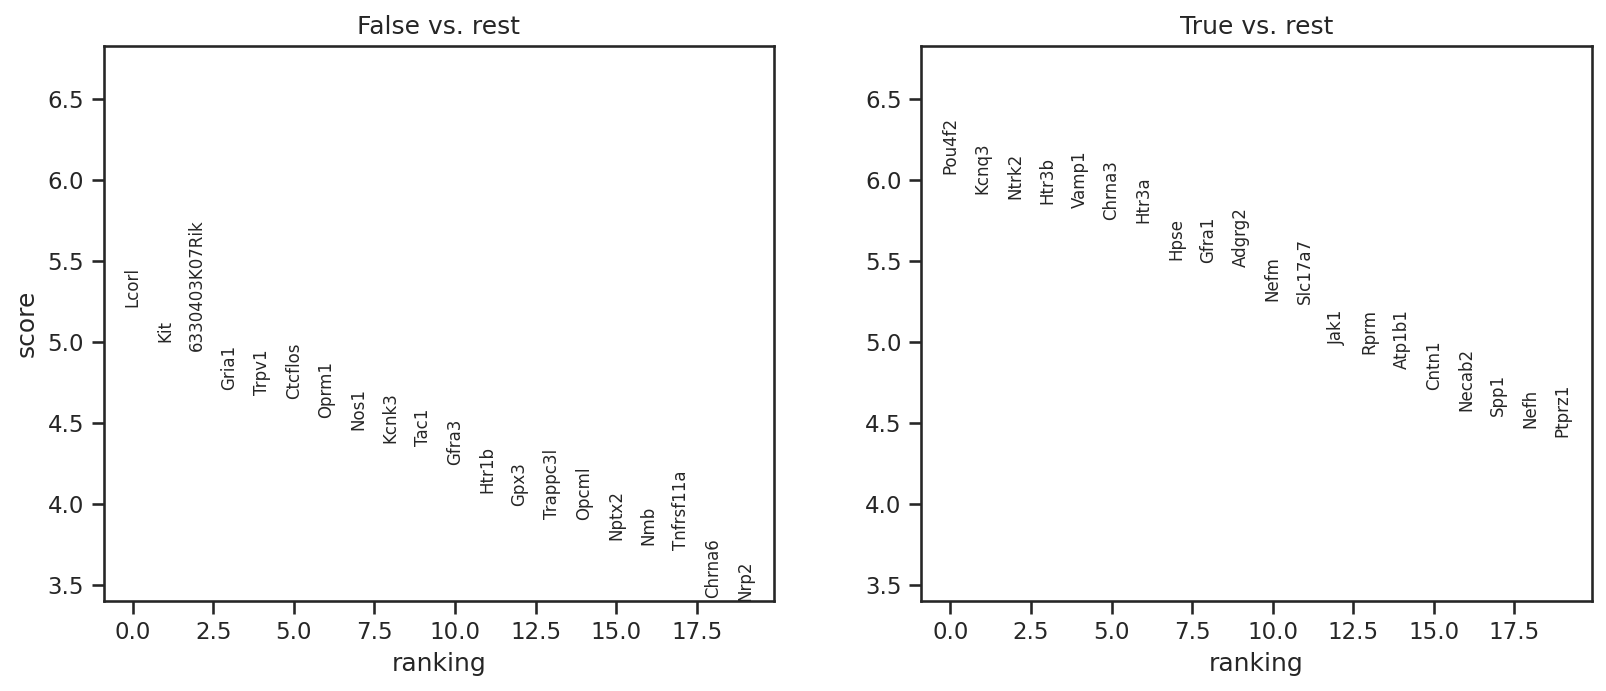

['Pou4f2', 'Kcnq3', 'Ntrk2', 'Htr3b', 'Vamp1', 'Chrna3', 'Htr3a', 'Hpse', 'Gfra1', 'Adgrg2']


In [28]:
adata_CGRPg.obs["EGFP_dTomato_dual_hi"] = adata_CGRPg.obs["EGFP_dTomato_dual_hi"].astype(str)
sc.tl.rank_genes_groups(adata_CGRPg, groupby="EGFP_dTomato_dual_hi", method="wilcoxon")

markers = sc.get.rank_genes_groups_df(adata_CGRPg, group=None)

# plot 
sc.pl.rank_genes_groups(adata_CGRPg, groupby="EGFP_dTomato_dual_hi", method="wilcoxon")

# top dual+ genes
top_genes_dual = (
    markers[markers["group"] == "True"]
    .head(10)["names"]
    .tolist()
)

print(top_genes_dual)

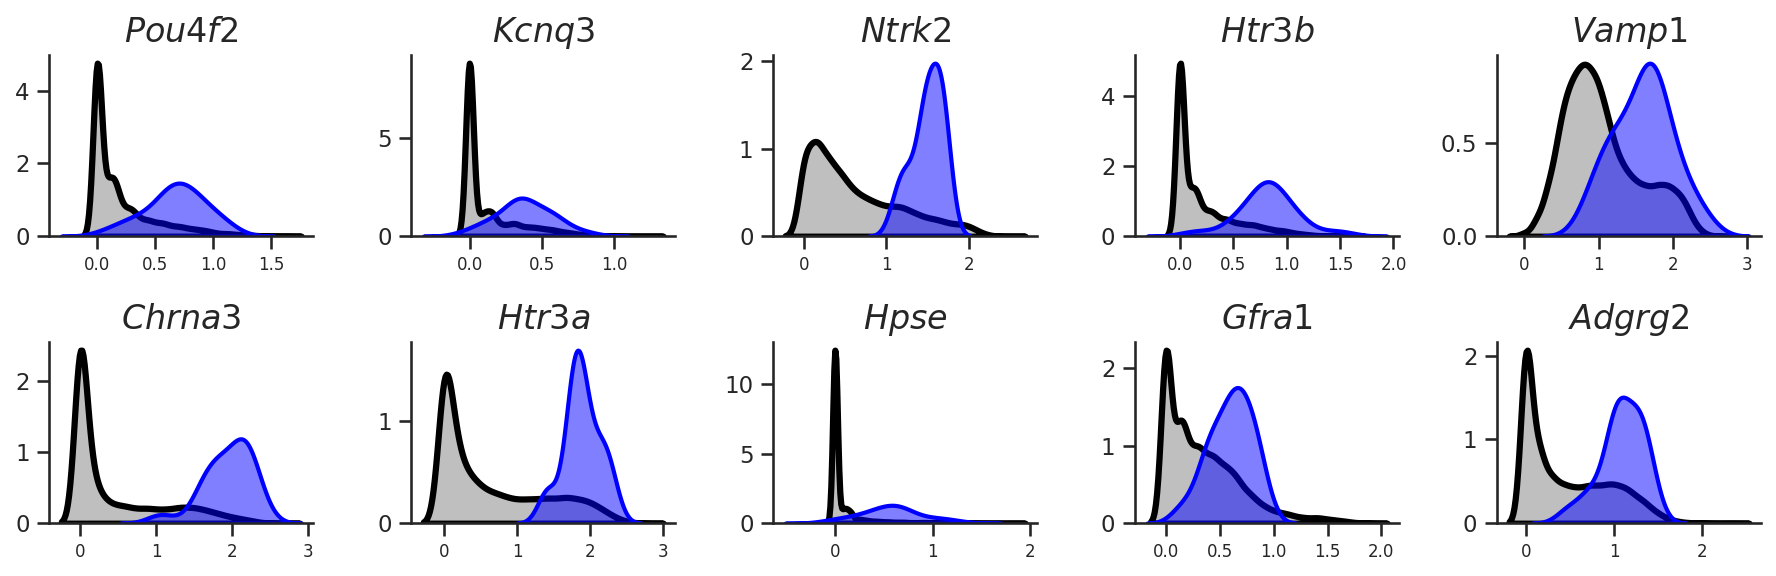

In [29]:
fig = kde_grid_plot(
    adata,
    genes=top_genes_dual,
    group_col="EGFP_dTomato_dual_hi",
    ncols=5,
    figsize=(12, 4),
    gene_fontsize = 16
)
plt.savefig(os.path.join(plot_out_dir, "dual_postive_comparison_CGRPgamma_top10_5cols.pdf"), format='pdf', bbox_inches='tight')

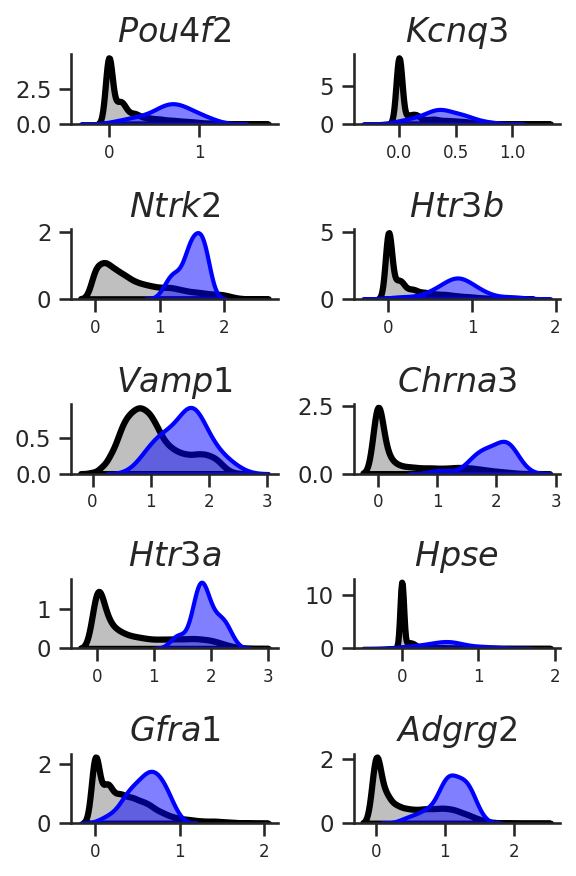

In [30]:
fig = kde_grid_plot(
    adata,
    genes=top_genes_dual,
    group_col="EGFP_dTomato_dual_hi",
    ncols=2,
    figsize=(4,6),
    gene_fontsize = 16
)
plt.savefig(os.path.join(plot_out_dir, "dual_postive_comparison_CGRPgamma_top10_2cols.pdf"), format='pdf', bbox_inches='tight')

## Check Cysltr2 expression

In [65]:
# plt.rcdefaults()
# import scanpy as sc
# sc.settings.set_figure_params(style='scanpy', format='png')
plt.rcParams['figure.figsize'] = (3,4)

In [80]:
len(adata.obs)

22411

In [82]:
n_sst = sum(adata.obs['neuron_label'].isin(['Sst']))
frac_sst = n_sst/len(adata.obs)
print(f"sst neuron count = {n_sst}, which is {frac_sst} fraction of the total neurons")

sst neuron count = 554, which is 0.024720003569675606 fraction of the total neurons


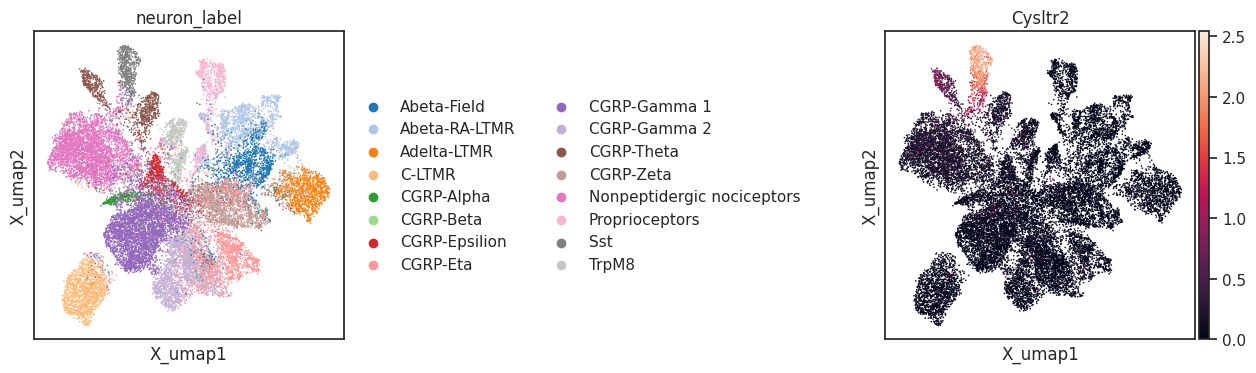

In [69]:
sc.pl.embedding(adata, basis = 'X_umap', color = ['neuron_label', 'Cysltr2'], wspace = 1.5)

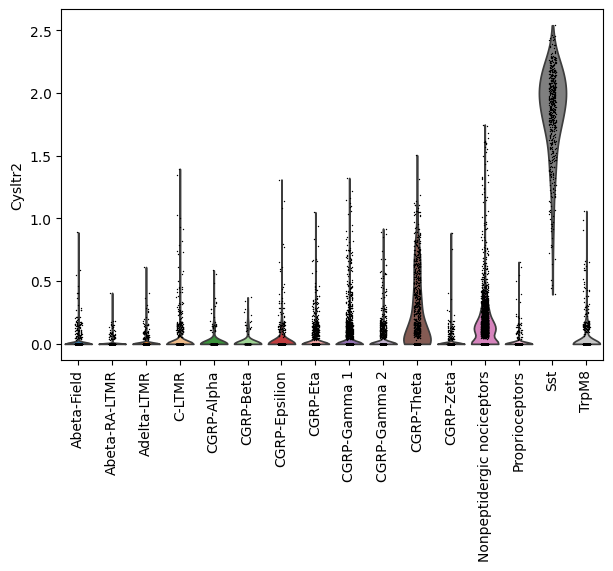

In [50]:
sc.pl.violin(adata, groupby='neuron_label', keys = ['Cysltr2'], rotation = 90)

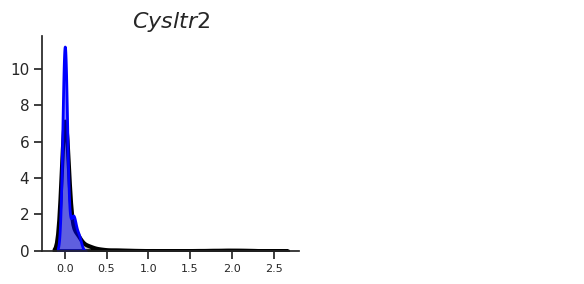

In [72]:
fig = kde_grid_plot(
    adata,
    genes=['Cysltr2'],
    group_col="EGFP_dTomato_dual_hi",
    ncols=2,
    figsize=(6,3),
    gene_fontsize = 16
)
# plt.savefig(os.path.join(plot_out_dir, "dual_postive_comparison_CGRPgamma_top10_2cols.pdf"), format='pdf', bbox_inches='tight')

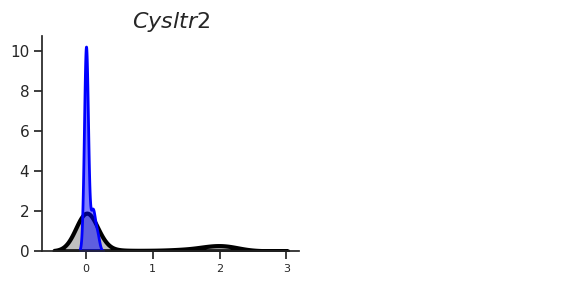

In [77]:
adata_cgrpgamma_sst = adata[adata.obs['neuron_label'].isin(['CGRP-Gamma 2', 'Sst']), :].copy()
fig = kde_grid_plot(
    adata_cgrpgamma_sst,
    genes=['Cysltr2'],
    group_col="EGFP_dTomato_dual_hi",
    ncols=2,
    figsize=(6,3),
    gene_fontsize = 16
)
# plt.savefig(os.path.join(plot_out_dir, "dual_postive_comparison_CGRPgamma_top10_2cols.pdf"), format='pdf', bbox_inches='tight')

In [60]:
def kde_multi_group_grid(
    adata,
    genes,
    group_col="neuron_label",   # Column with multiple categories
    ncols=5,
    figsize=(15, 8),
    gene_fontsize=14,
    palette=None                # Optional: dict of {cat: color}
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import math

    sns.set_theme(style="ticks")

    # 1. Prepare Data
    # Get expression and groups in one clean dataframe
    df = adata.to_df()[genes].copy()
    df[group_col] = adata.obs[group_col].astype(str).replace("nan", "Unknown").values
    
    categories = sorted(df[group_col].unique())

    # 2. Setup Colors
    # If palette is not provided, try to grab from adata.uns or use a default
    if palette is None:
        uns_color_key = f"{group_col}_colors"
        if uns_color_key in adata.uns:
            palette = dict(zip(adata.obs[group_col].cat.categories, adata.uns[uns_color_key]))
        else:
            palette = dict(zip(categories, sns.color_palette("husl", len(categories))))

    # 3. Setup Grid
    n = len(genes)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=False,
        sharey=False
    )
    
    # Handle case where only 1 gene is plotted
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # 4. Plotting Loop
    for i, gene in enumerate(genes):
        ax = axes[i]
        
        # Plot a KDE for every category
        for cat in categories:
            subset = df[df[group_col] == cat]
            
            # Skip if no data for this category to avoid KDE errors
            if subset.shape[0] < 2:
                continue

            sns.kdeplot(
                data=subset,
                x=gene,
                ax=ax,
                fill=True,
                color=palette.get(cat, "grey"),
                alpha=0.2,
                linewidth=1.5,
                label=cat
            )

        # Title: Italicized Gene Name
        ax.set_title(f"$\\it{{{gene}}}$", fontsize=gene_fontsize)
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=8)

    # Clean up: Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    # 5. Add a single Legend to the figure
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

    sns.despine()
    plt.tight_layout()

    return fig

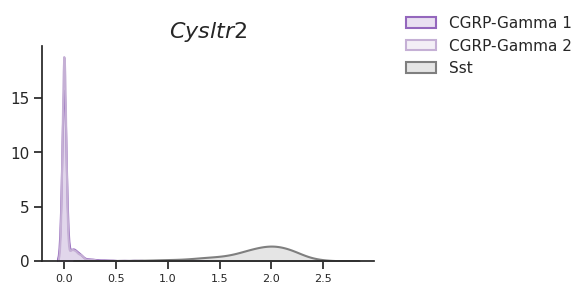

In [79]:
adata_cgrpgamma_sst = adata[adata.obs['neuron_label'].isin(['CGRP-Gamma 1', 'CGRP-Gamma 2', 'Sst']), :].copy()
fig = kde_multi_group_grid(
    adata_cgrpgamma_sst,
    genes=['Cysltr2'],
    group_col="neuron_label",
    ncols=1,
    figsize=(4,3),
    gene_fontsize = 16
)
# plt.savefig(os.path.join(plot_out_dir, "dual_postive_comparison_CGRPgamma_top10_2cols.pdf"), format='pdf', bbox_inches='tight')